# Probability of Fire (PoF) — Plotting with Subsection of Dataset

**Master:** Physics of Data \
**Course:** Laboratory of Computational Physics (LCP), Module B \
**Authors:** Gabriela Landinez Rangel, Andres Rojas Lozano, Fatemeh Dashti, Arash Taraz Jamshidi

*This notebook was created by us to present the final project for LCP MOD B, However it is based on public available code from the Probability of Fire project by ECMWF: https://ecmwf.github.io/AI-Probability-of-Fire/plotting/. With this work, we aim to provide a clear, but friendly, guide with straightforward instructions and detailed explanations for students who, like us, want to reproduce this framework.*

# Libraries
The code below imports the libraries needed for numerical work, NetCDF files, and geographic plotting.

In [14]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import cm
from matplotlib.colors import Normalize
import numpy as np
import xarray as xr
import matplotlib as mpl
from cartopy import config
import cartopy.crs as ccrs
import cartopy as cart
import sys
import datetime
from matplotlib.colors import ListedColormap,LinearSegmentedColormap


# OPEN SELECTED REDUCED-FEATURE FORECAST

| Model              | Features                     | Scientific question                  |
| ------------------ | ---------------------------- | ------------------------------------ |
| Full model         | all 13 features              | baseline                             |
| Weather-only       | `PR, T2, RH, WS`             | can weather alone explain fire risk? |
| Weather + moisture | `PR, T2, RH, WS, DF, DW, LF` | does fuel dryness improve the model? |
| Weather + human    | `PR, T2, RH, WS, PO, RD`     | do ignition proxies help?            |
| Moisture-only      | `DF, DW, LF`                 | how much comes from fuel moisture?   |


## Select which reduced-feature forecast to plot

This cell chooses which reduced-feature model output will be opened and plotted.  
Only **one** `model_tag` should be active at a time. The other lines should remain commented with `#`.

Available options:

- `weather_only`: uses precipitation, temperature, relative humidity, and wind;
- `weather_moisture`: uses weather variables plus fuel-moisture variables;
- `weather_human`: uses weather variables plus population and road-density proxies;
- `moisture_only`: uses only fuel-moisture variables.

The value of `model_tag` is later inserted into the file name, for example:

```python
POF_prediction_2019_12_weather_moisture.nc
```

If all lines are commented, the notebook will not know which model to plot.


In [ ]:
#model_tag = "weather_only" 

#model_tag = "weather_moisture"                

#model_tag = "weather_human"

#model_tag = "moisture_only"

## Open the selected reduced-feature forecast file 

In [13]:
import xarray as xr

year = 2019
month = 12

#--------------------------------------------------------------------------------

input_file = f"./outputs/POF_prediction_{year}_{month:02d}_{model_tag}.nc"

print("Opening:")
print(input_file)

ds_model = xr.open_dataset(input_file)

pof_var = list(ds_model.data_vars)[0]
pof_model = ds_model[pof_var]

print(ds_model)
print("POF variable:", pof_var)

Opening:
./outputs/POF_prediction_2019_12_full.nc
<xarray.Dataset> Size: 2GB
Dimensions:           (time: 31, latitude: 1801, longitude: 3600)
Coordinates:
  * time              (time) object 248B 2019-12-01 00:00:00 ... 2019-12-31 0...
  * latitude          (latitude) float64 14kB 90.0 89.9 89.8 ... -89.9 -90.0
  * longitude         (longitude) float64 29kB 0.0 0.1 0.2 ... 359.7 359.8 359.9
Data variables:
    fire_probability  (time, latitude, longitude) float64 2GB ...
POF variable: fire_probability


## Define a helper function to select a geographic region

This cell defines `select_region`, a reusable function that cuts out a latitude-longitude box from the global forecast map.

The function is careful about latitude order. Some datasets store latitude from north to south, while others store it from south to north. The `if` statement checks the order and chooses the correct slicing direction.

The final call selects the Australia domain:

```text
latitude:  -45 to -10
longitude: 110 to 155
```

The output, `aus_weather`, is the selected regional probability field.


In [12]:
def select_region(da, lat_min, lat_max, lon_min, lon_max):
    lat_values = da.latitude.values

    if lat_values[0] > lat_values[-1]:
        lat_slice = slice(lat_max, lat_min)
    else:
        lat_slice = slice(lat_min, lat_max)

    return da.sel(
        latitude=lat_slice,
        longitude=slice(lon_min, lon_max)
    )


aus_weather = select_region(
    pof_model,
    lat_min=-45,
    lat_max=-10,
    lon_min=110,
    lon_max=155
)

In [11]:
year = 2019
month = 12

import xarray as xr


fire = xr.open_dataset(input_file)

fire = fire.assign_coords(
    longitude=((fire.longitude + 360) % 360)
).sortby("longitude")

lats = fire.latitude.values
lons = fire.longitude.values

fire


<xarray.Dataset> Size: 2GB
Dimensions:           (time: 31, latitude: 1801, longitude: 3600)
Coordinates:
  * time              (time) object 248B 2019-12-01 00:00:00 ... 2019-12-31 0...
  * latitude          (latitude) float64 14kB 90.0 89.9 89.8 ... -89.9 -90.0
  * longitude         (longitude) float64 29kB 0.0 0.1 0.2 ... 359.7 359.8 359.9
Data variables:
    fire_probability  (time, latitude, longitude) float64 2GB ...

## Select the Australia sub-domain for plotting

This cell defines the geographic box used in the original `pof4` plot.

The latitude and longitude bounds are:

```text
lat1 = -10
lat2 = -45
lon1 = 110
lon2 = 155
```

Then `fire.sel(...)` extracts only this regional subset from the global forecast file.

The result, `sub_ds`, is still an xarray dataset, but it now contains only the Australia region instead of the whole world.

In [15]:
lat1 = -10
lat2 = -45
lon1 = 110
lon2 = 155

sub_ds = fire.sel(
    latitude=slice(lat1, lat2), 
    longitude=slice(lon1, lon2)
)

sub_ds


<xarray.Dataset> Size: 39MB
Dimensions:           (time: 31, latitude: 350, longitude: 451)
Coordinates:
  * time              (time) object 248B 2019-12-01 00:00:00 ... 2019-12-31 0...
  * latitude          (latitude) float64 3kB -10.0 -10.1 -10.2 ... -44.8 -44.9
  * longitude         (longitude) float64 4kB 110.0 110.1 110.2 ... 154.9 155.0
Data variables:
    fire_probability  (time, latitude, longitude) float64 39MB ...

In [16]:
cols = ['#4a5a60','#edcc00','#edcc00','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e21819','#e21819','#e21819','#e21819','#e21819','#000000','#000000']
test = ListedColormap(cols)

In [17]:
index=0 # Which index to plot (1st of the month)

fires = sub_ds.fire_probability[index].values
plot_title = f"Probability of Fire Forecast for {sub_ds.time.values[index].strftime('%d %B %Y') }"

fires[fires>0.006]=0.006 # 1km

levels = np.arange(16)/2500 # 1km

print(np.shape(fires))
#print(np.nanmax(fire.fire_probability.values))
#print(np.nanmin(fire.fire_probability.values))
#print(np.nanmean(fire.fire_probability.values))

(350, 451)


C:\Users\sisto\anaconda3\Anaconda_new\envs\pof-fire\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


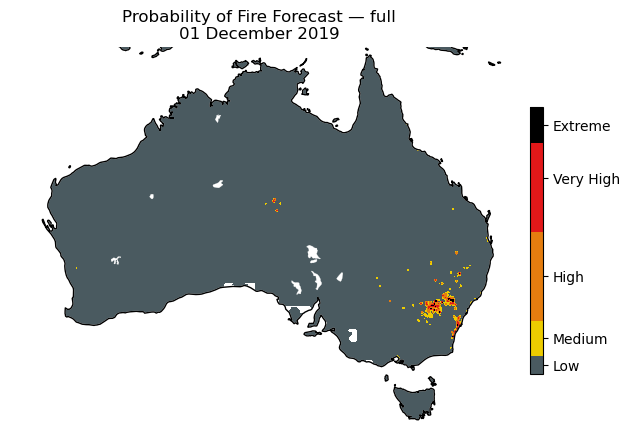

In [10]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

fig = ax.contourf(sub_ds.longitude, sub_ds.latitude, fires,levels=levels,vmin=0,vmax=0.006,transform=ccrs.PlateCarree(),cmap=test)

ax.add_feature(cart.feature.OCEAN,zorder=1,edgecolor='k',color='white')
ax.add_feature(cart.feature.BORDERS,linewidth=0.5,color='white')
ax.add_feature(cart.feature.LAKES,color='white', edgecolor='k', linewidth=0.2, zorder=2)

states_provinces = cart.feature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        edgecolor='black'
)

for spine in ax.spines.values():
   spine.set_visible(False)

cbar = plt.colorbar(fig,ticks=[0.0002,0.0008,0.0022,0.0044,0.0056],fraction=0.025, pad=0.04)
cbar.ax.set_yticklabels(['Low', 'Medium','High', 'Very High', 'Extreme'])

plt.title(f"Probability of Fire Forecast — {model_tag}\n01 December 2019")

plt.tight_layout()

plt.savefig(f"./outputs/My_PoF_Plot_{model_tag}.png", dpi=300)


### CHECK THE ACTUAL MAP VALUES HERE (moisture_only)
Diagnostic check: inspect the actual plotted probability values

This cell checks the numerical values inside the plotted map variable `fires`.

It prints:

- number of valid cells;
- minimum probability;
- maximum probability;
- mean probability;
- median probability;
- selected quantiles;
- how many grid cells fall into each color-class interval.

This is useful for understanding whether a map looks uniform because of the plotting scale or because the model predicted nearly identical probabilities everywhere.

In [ ]:
import numpy as np

valid_values = fires[np.isfinite(fires)]

print("Number of valid cells:", len(valid_values))
print("Min:", np.nanmin(valid_values))
print("Max:", np.nanmax(valid_values))
print("Mean:", np.nanmean(valid_values))
print("Median:", np.nanmedian(valid_values))
print("Quantiles:", np.nanpercentile(valid_values, [0, 5, 25, 50, 75, 95, 99, 100]))

# optional: how many cells fall into each class
print("Count <= 0.0002:", np.sum(valid_values <= 0.0002))
print("Count 0.0002–0.0008:", np.sum((valid_values > 0.0002) & (valid_values <= 0.0008)))
print("Count 0.0008–0.0022:", np.sum((valid_values > 0.0008) & (valid_values <= 0.0022)))
print("Count 0.0022–0.0044:", np.sum((valid_values > 0.0022) & (valid_values <= 0.0044)))
print("Count > 0.0044:", np.sum(valid_values > 0.0044))

Number of valid cells: 155975
Min: 0.00046784570440649986
Max: 0.00046784570440649986
Mean: 0.00046784570440649986
Median: 0.00046784570440649986
Quantiles: [0.00046785 0.00046785 0.00046785 0.00046785 0.00046785 0.00046785
 0.00046785 0.00046785]
Count <= 0.0002: 0
Count 0.0002–0.0008: 155975
Count 0.0008–0.0022: 0
Count 0.0022–0.0044: 0
Count > 0.0044: 0


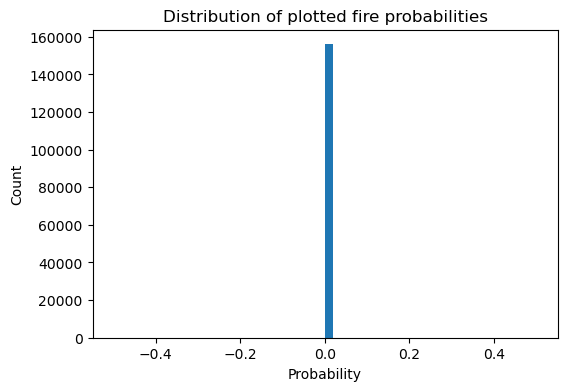

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(valid_values, bins=50)
plt.title("Distribution of plotted fire probabilities")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

The moisture-only model produced an almost uniform probability field. 
The diagnostic check confirmed that all valid grid cells had the same predicted probability. 
This suggests that fuel-moisture variables alone were not sufficient to create spatial discrimination in the forecast. 
Therefore, weather and other predictors are necessary for a meaningful Probability of Fire map.